# Immunity modeling

## Imports

In [1]:
import sys
import os

module_path = os.path.abspath(os.path.join('..', 'src'))
sys.path.insert(0, module_path)

In [2]:
import plotly.graph_objects as go
from src.models.immunity import immunity_by_year_day

## Visualization

In [7]:
def create_interactive_range_test():
    """
    Create interactive plot to test different ranges.
    """
    days = list(range(365*4+1))
    
    fig = go.Figure()
    
    # Test multiple ranges with different colors
    test_ranges = [
        (0, 1, '#1f77b4'),
        (0.2, 1.0, '#ff7f0e'), 
        (0.25, 0.8, '#2ca02c'),
        (0.1, 0.9, '#9467bd')
    ]
    
    for low, high, color in test_ranges:
        values = [immunity_by_year_day(day, low, high) for day in days]
        fig.add_trace(go.Scatter(
            x=days, y=values,
            mode='lines',
            name=f'[{low}, {high}]',
            line=dict(color=color, width=2.5),
            hovertemplate='Day: %{x}<br>Value: %{y:.2f}<br>Range: [' + f'{low}, {high}]'
        ))
    
    fig.update_layout(
        title="Pascal's Snail Function for Immunity Modeling  - Multiple Output Ranges",
        xaxis_title="Day of Year",
        yaxis_title="Output Value",
        template="plotly_white",
        height=500,
        hovermode='x unified'
    )
    
    return fig

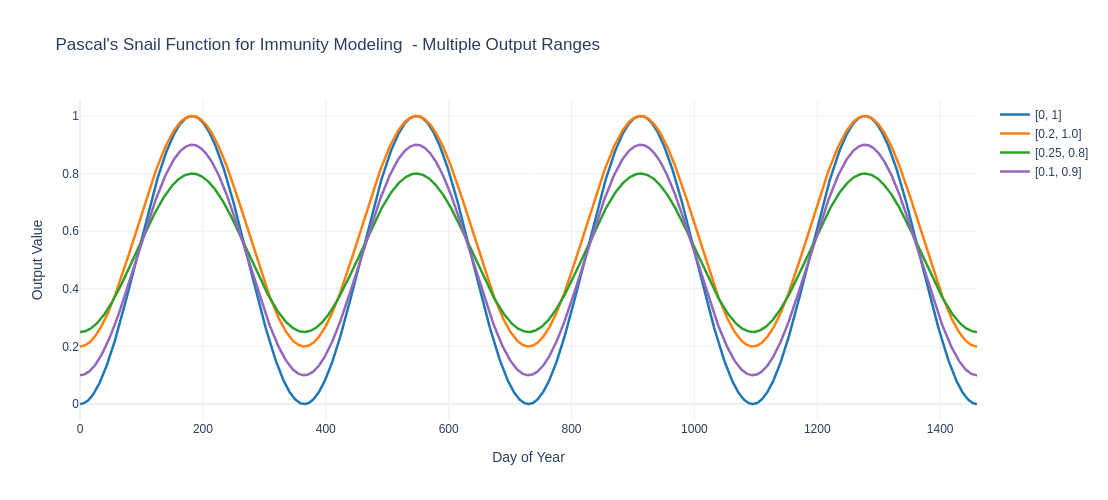

In [8]:
interactive_fig = create_interactive_range_test()
interactive_fig.show()

In [9]:
test_days = [0, 30, 91, 182, 273, 334, 365]
results = []
for day in test_days:
    results.append(round(immunity_by_year_day(day=day, low=0.0, high=1.0), 2))

In [10]:
results

[0.0, 0.07, 0.5, 1.0, 0.51, 0.07, 0.0]